# Data Preparation

In [324]:
# Import Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [325]:
# Load the Dataset
df = pd.read_excel('airline_ticket_dataset.xlsx')

# Find rows with any NaN value and the corresponding column names
rows_with_nan = df[df.isnull().any(axis=1)]

# To identify which specific columns are empty in those rows:
for index, row in rows_with_nan.iterrows():
    print(f"Row {index} has empty columns: {list(row.index[row.isnull()])}")
    
# Drop rows with any NaN values
df = df.dropna()

Row 602 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 906 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 1641 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 2772 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 2805 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 3701 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 3924 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 4939 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 4955 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 5662 has empty columns: ['TotalFaredPax_city2', 'TotalPerLFMkts_city2', 'TotalPerPrem_city2']
Row 5893 has empty col

### Feature Descriptions
- Year	
- quarter
- citymarketid_1: City Market ID (Endpoint 1)
- citymarketid_2: City Market ID (Endpoint 2)
- city1: City Name (Endpoint 1)
- city2: City Name (Endpoint 2)
- nsmiles: Nonstop Distance (miles)
- passengers: Passengers per Day for the specific trip from city1 to city2
- fare: Average Market Fare
- carrier_lg: Largest Share Carrier
- large_ms: Largest Carrier Market Share
- fare_lg: Largest Carrier Avg Fare
- carrier_low: Lowest Fare Carrier
- lf_ms: Lowest Fare Carrier Market Share
- fare_low:	Lowest Carrier Avg Fare
- TotalFaredPax_city1: Total Fare-Paying Passengers from (City 1)
- TotalPerLFMkts_city1:	% of markets (routes) from that city that are served by low-fare carriers (City 1)
- TotalPerPrem_city1: Fare Premium % (City 1)
- TotalFaredPax_city2: Total Fare-Paying Passengers (City 2)
- TotalPerLFMkts_city2:	% of markets (routes) from that city that are served by low-fare carriers (City 2)
- TotalPerPrem_city2: Fare Premium % (City 2)

In [326]:
# Display the first few rows of the dataset
df.head()

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,nsmiles,passengers,fare,carrier_lg,...,fare_lg,carrier_low,lf_ms,fare_low,TotalFaredPax_city1,TotalPerLFMkts_city1,TotalPerPrem_city1,TotalFaredPax_city2,TotalPerLFMkts_city2,TotalPerPrem_city2
0,2025,2,32467,31703,"Miami, FL (Metropolitan Area)","New York City, NY (Metropolitan Area)",1118,17955,208.52,B6,...,191.48,B6,0.2551,191.48,4.322090e+06,0.88590,-0.065800,2.978413e+06,0.821150,-0.032867
1,2025,2,32575,32457,"Los Angeles, CA (Metropolitan Area)","San Francisco, CA (Metropolitan Area)",372,17310,157.68,WN,...,169.03,AS,0.1193,140.59,2.822942e+06,0.86508,-0.038060,3.284783e+06,0.880833,-0.051467
2,2025,2,32575,31703,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",2510,13648,430.38,DL,...,526.21,B6,0.2272,365.63,2.822942e+06,0.86508,-0.038060,2.978413e+06,0.821150,-0.032867
3,2025,2,31703,31454,"New York City, NY (Metropolitan Area)","Orlando, FL",989,12627,186.50,B6,...,186.10,B6,0.3735,186.10,2.978413e+06,0.82115,-0.032867,8.664260e+06,0.979700,-0.115500
4,2025,2,30977,31703,"Chicago, IL","New York City, NY (Metropolitan Area)",773,11284,221.33,UA,...,238.62,AA,0.2426,217.36,5.402975e+06,0.77515,-0.007850,2.978413e+06,0.821150,-0.032867


In [327]:
# Display the summary statistics of the dataset
df.describe()

,Year,quarter,citymarketid_1,citymarketid_2,nsmiles,passengers,fare,large_ms,fare_lg,lf_ms,fare_low,TotalFaredPax_city1,TotalPerLFMkts_city1,TotalPerPrem_city1,TotalFaredPax_city2,TotalPerLFMkts_city2,TotalPerPrem_city2
count,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,13972.000000,1.397200e+04,13972.000000,13972.000000,1.397200e+04,13972.000000,13972.000000
mean,2023.285786,2.357572,31505.514314,32297.180003,1062.042657,1026.331663,237.945480,0.565345,245.978231,0.326349,181.074192,3.216491e+06,0.836194,-0.007129,2.953107e+06,0.832620,-0.038564
std,1.030209,1.108642,1214.535823,1419.321109,590.528719,1477.214105,63.772095,0.173237,77.389870,0.226153,69.256378,2.316909e+06,0.141120,0.108174,2.011599e+06,0.142595,0.119847
min,2022.000000,1.000000,30135.000000,30189.000000,129.000000,163.000000,76.770000,0.209700,76.770000,0.010000,66.160000,2.993000e+04,0.000000,-0.619400,5.464000e+04,0.000000,-0.641100
25%,2022.000000,1.000000,30529.000000,30852.000000,602.000000,317.000000,193.330000,0.431500,193.770000,0.154375,119.695000,1.224800e+06,0.793500,-0.051300,1.579690e+06,0.788100,-0.077000
50%,2023.000000,2.000000,31057.000000,32211.000000,936.000000,528.000000,227.860000,0.540950,239.425000,0.264800,175.380000,2.873210e+06,0.865900,-0.003150,2.764620e+06,0.863200,-0.022500
75%,2024.000000,3.000000,32244.000000,33342.000000,1405.500000,1090.000000,275.760000,0.675500,294.052500,0.442700,225.990000,4.254110e+06,0.922500,0.048600,3.661990e+06,0.939300,0.040500
max,2025.000000,4.000000,35412.000000,35628.000000,2724.000000,21058.000000,676.890000,1.000000,679.120000,1.000000,669.740000,8.840080e+06,1.000000,0.965900,8.840080e+06,1.000000,0.350800


# Data Exploration

In [328]:
# Explore the fare distribution for different cities and routes
city1_means = df.groupby('city1')['fare'].mean().sort_values(ascending=False)
city2_means = df.groupby('city2')['fare'].mean().sort_values(ascending=False)
print("Average Fare by City 1:")
print(city1_means)
print("\nAverage Fare by City 2:")
print(city2_means)

Average Fare by City 1:
city1
Eagle, CO                         562.593750
Jackson, WY                       497.232500
Aspen, CO                         485.018750
Tucson, AZ                        358.234286
Key West, FL                      321.033000
                                     ...    
Harrisburg, PA                    107.040000
Allentown/Bethlehem/Easton, PA    105.568571
Atlantic City, NJ                 105.414651
Trenton, NJ                       105.263333
Belleville, IL                     89.303333
Name: fare, Length: 116, dtype: float64

Average Fare by City 2:
city2
Steamboat Springs, CO              373.220000
Bozeman, MT                        355.730000
Key West, FL                       322.798571
Palm Springs, CA                   310.976383
Atlanta, GA (Metropolitan Area)    305.855714
                                      ...    
South Bend, IN                     121.140000
New Haven, CT                      118.101053
Sanford, FL                        1

In [329]:
# Explore the distribution of fare prices per quarter
quarter_means = df.groupby('quarter')['fare'].mean()
print("Average Fare by Quarter:")
print(quarter_means)

Average Fare by Quarter:
quarter
1    235.285503
2    242.206644
3    230.244007
4    243.504476
Name: fare, dtype: float64


In [330]:
# Explore the distribution of most popular cities
city1_counts = df['city1'].value_counts().sort_values(ascending=False)
city2_counts = df['city2'].value_counts().sort_values(ascending=False)
print("Most Popular City 1:")
print(city1_counts)
print("\nMost Popular City 2:")
print(city2_counts)

Most Popular City 1:
city1
Chicago, IL                        756
Dallas/Fort Worth, TX              739
Atlanta, GA (Metropolitan Area)    738
Denver, CO                         713
Boston, MA (Metropolitan Area)     652
                                  ... 
Pasco/Kennewick/Richland, WA         2
Santa Rosa, CA                       2
Billings, MT                         2
Medford, OR                          2
Punta Gorda, FL                      1
Name: count, Length: 116, dtype: int64

Most Popular City 2:
city2
Washington, DC (Metropolitan Area)       932
Tampa, FL (Metropolitan Area)            658
New York City, NY (Metropolitan Area)    621
Seattle, WA                              608
Phoenix, AZ                              577
                                        ... 
Worcester, MA                              2
Steamboat Springs, CO                      1
Missoula, MT                               1
Eugene, OR                                 1
South Bend, IN             

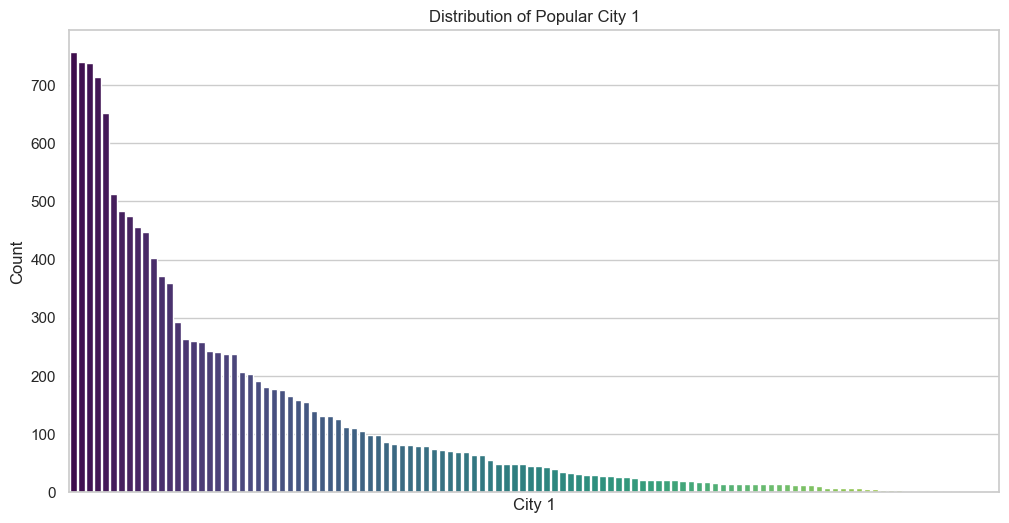

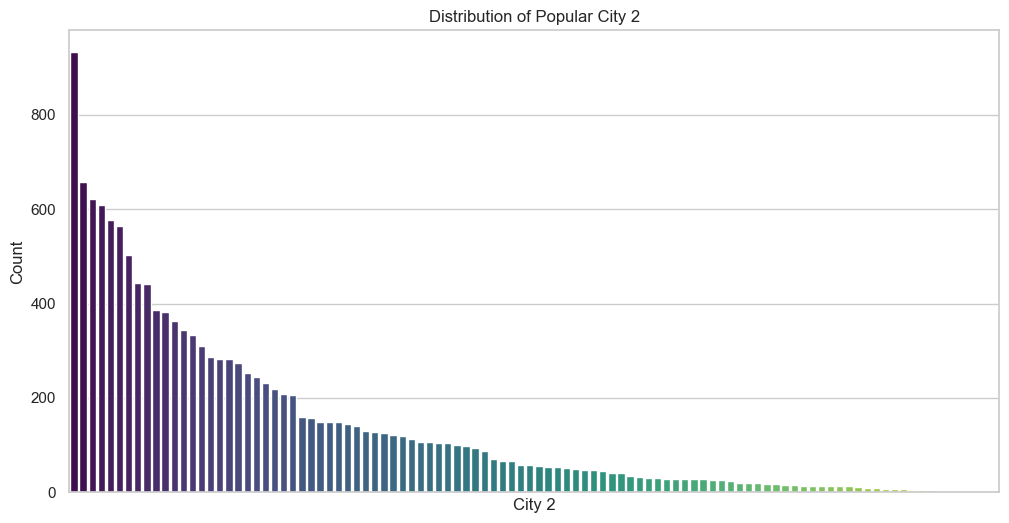

In [331]:
# Plot the distribution of popular cities
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=city1_counts.index, y=city1_counts.values, palette='viridis')
ax.tick_params(axis='x', labelbottom=False)
plt.title('Distribution of Popular City 1')
plt.xlabel('City 1')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=city2_counts.index, y=city2_counts.values, palette='viridis')
ax.tick_params(axis='x', labelbottom=False)
plt.title('Distribution of Popular City 2')
plt.xlabel('City 2')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [332]:
# Explore the monopoly power of airlines
airline_counts = df['carrier_lg'].value_counts()
airline_fares = df.groupby('carrier_lg')['fare_lg'].mean()
print("Airline Counts:")
print(airline_counts)
print("\nAverage Fare by Airline:")
print(airline_fares)

Airline Counts:
carrier_lg
WN    3836
AA    2830
DL    2778
UA    1894
AS     970
B6     569
G4     401
NK     241
F9     227
MX     108
XP      68
SY      50
Name: count, dtype: int64

Average Fare by Airline:
carrier_lg
AA    285.957226
AS    242.185515
B6    215.113409
DL    284.432970
F9    115.567401
G4    114.903217
MX    119.552778
NK    110.517884
SY    150.504600
UA    283.166837
WN    212.945487
XP    110.529706
Name: fare_lg, dtype: float64


In [333]:
# Explore the distribution of premium market fare prices
city1_premium_fare_means = (
    df.groupby('city1')
    .filter(lambda x: len(x) > 100)
    .groupby('city1')['TotalPerPrem_city1']
    .mean()
    .sort_values(ascending=False)
)
city2_premium_fare_means = (
    df.groupby('city2')
    .filter(lambda x: len(x) > 100)
    .groupby('city2')['TotalPerPrem_city2']
    .mean()
    .sort_values(ascending=False)
)
print("Average Premium Fare by City 1:")
print(city1_premium_fare_means.head(10))
print("\nAverage Premium Fare by City 2:")
print(city2_premium_fare_means.head(10))

Average Premium Fare by City 1:
city1
Charlotte, NC                      0.158492
Birmingham, AL                     0.139572
Salt Lake City, UT                 0.129648
Atlanta, GA (Metropolitan Area)    0.123829
Detroit, MI                        0.107170
Philadelphia, PA                   0.058319
Dallas/Fort Worth, TX              0.058147
Minneapolis/St. Paul, MN           0.054849
Jacksonville, FL                   0.053481
Austin, TX                         0.031137
Name: TotalPerPrem_city1, dtype: float64

Average Premium Fare by City 2:
city2
Salt Lake City, UT                    0.130088
Detroit, MI                           0.107164
Norfolk, VA (Metropolitan Area)       0.105927
West Palm Beach/Palm Beach, FL        0.104685
Washington, DC (Metropolitan Area)    0.062388
Dallas/Fort Worth, TX                 0.058248
Philadelphia, PA                      0.058144
Minneapolis/St. Paul, MN              0.055007
Jacksonville, FL                      0.052024
Omaha, NE          

In [334]:
# Explore the relationship between distance and fare prices for cities that appear more than 100 times in the dataset
average_distance_city1 = (
    df.groupby('city1')
    .filter(lambda x: len(x) > 100)
    .groupby('city1')['nsmiles']
    .mean()
    .sort_values(ascending=False)
)
average_distance_city2 = (
    df.groupby('city2')
    .filter(lambda x: len(x) > 100)
    .groupby('city2')['nsmiles']
    .mean()
    .sort_values(ascending=False)
)
print("Average Distance from City1:")
print(average_distance_city1.head(10))
print("\nAverage Distance to City2:")
print(average_distance_city2.head(10))

Average Distance from City1:
city1
Philadelphia, PA                         1453.590909
Los Angeles, CA (Metropolitan Area)      1450.478261
Orlando, FL                              1399.734615
Hartford, CT                             1394.038462
New York City, NY (Metropolitan Area)    1294.858209
Miami, FL (Metropolitan Area)            1279.881720
Las Vegas, NV                            1250.338947
Boston, MA (Metropolitan Area)           1228.253067
Fort Myers, FL                           1177.958333
Jacksonville, FL                         1153.807143
Name: nsmiles, dtype: float64

Average Distance to City2:
city2
Portland, OR                             1655.063830
San Francisco, CA (Metropolitan Area)    1546.739362
Seattle, WA                              1535.615132
Los Angeles, CA (Metropolitan Area)      1506.217195
San Diego, CA                            1446.454955
Sacramento, CA                           1443.387755
Las Vegas, NV                            1350.405759


# Time Series Analysis

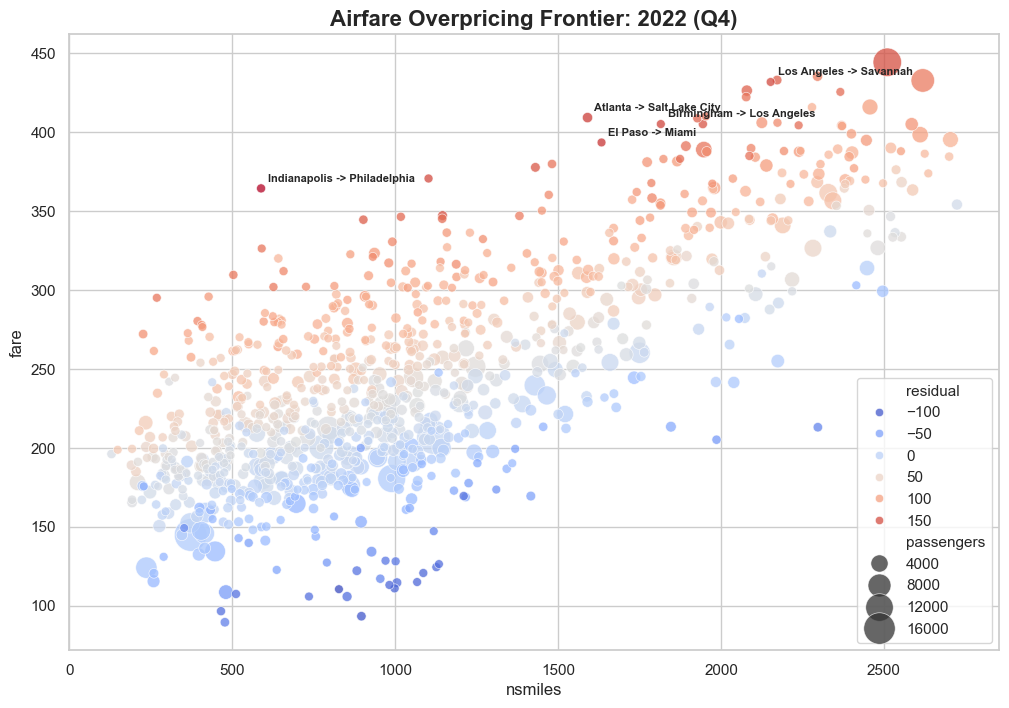

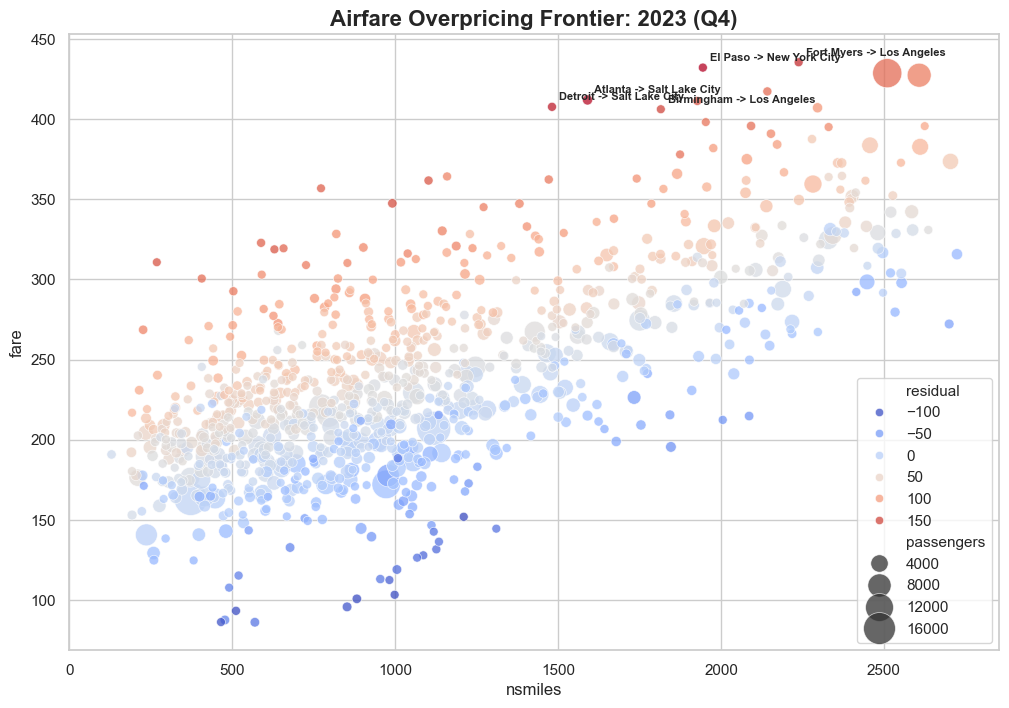

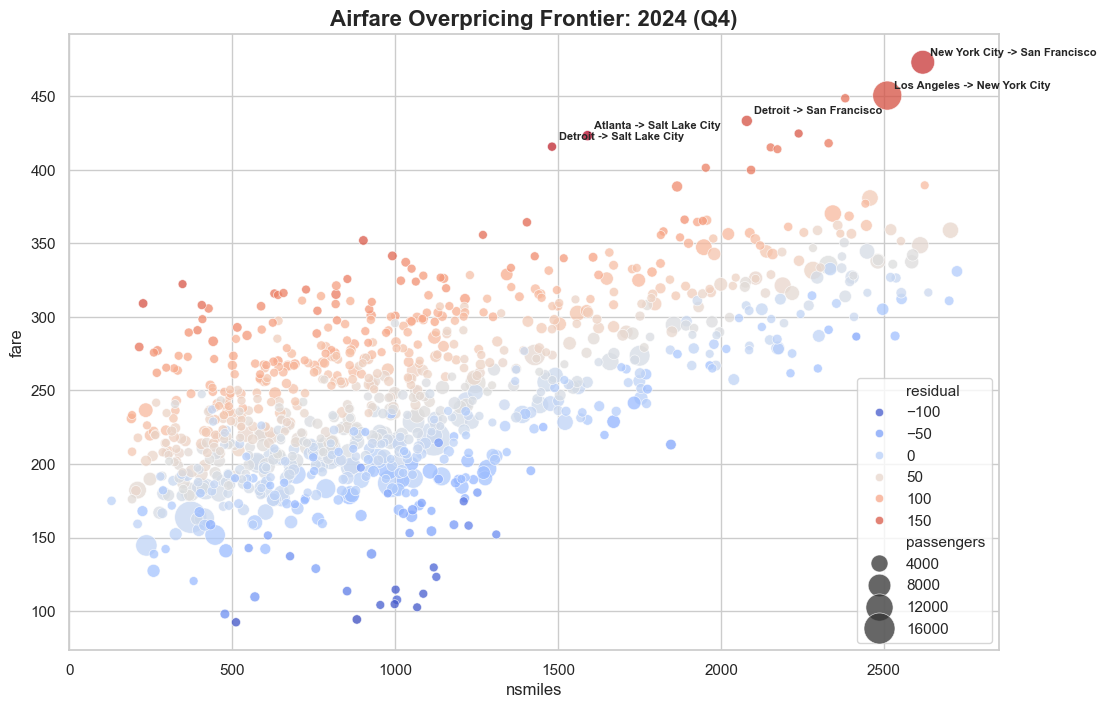

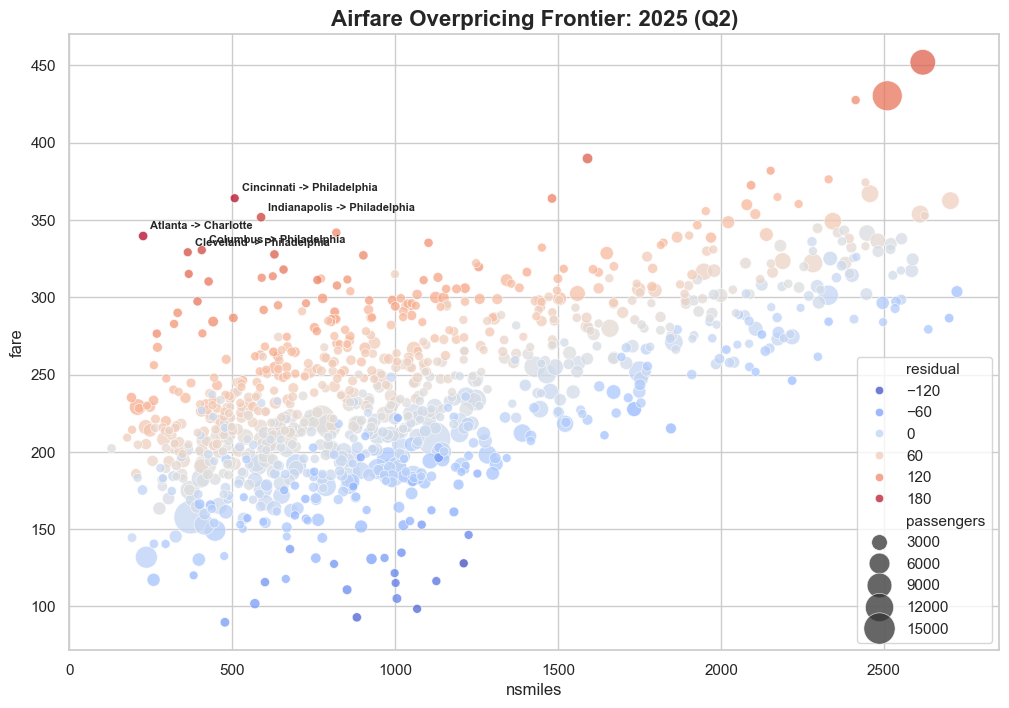

In [335]:
# Professional styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

df_copy = df.copy()

df_copy['Period'] = df_copy['Year'].astype(str) + ' Q' + df_copy['quarter'].astype(str)
df_copy['avg_lcc_pct'] = (df_copy['TotalPerLFMkts_city1'] + df_copy['TotalPerLFMkts_city2']) / 2
df_clean = df_copy.dropna(subset=['fare', 'nsmiles', 'avg_lcc_pct', 'large_ms', 'passengers'])

df['avg_lcc_pct'] = (df['TotalPerLFMkts_city1'] + df['TotalPerLFMkts_city2']) / 2
df_clean = df.dropna(subset=['fare', 'nsmiles', 'avg_lcc_pct', 'large_ms', 'passengers'])

# 2. Establish 2022 Q1 Baseline
df_base = df_clean[(df_clean['Year'] == 2022) & (df_clean['quarter'] == 1)]
X_base = sm.add_constant(df_base[['nsmiles', 'avg_lcc_pct', 'large_ms']])
model_base = sm.OLS(df_base['fare'], X_base).fit()

# 3. Loop through each year
for year in sorted(df_clean['Year'].unique()):
    # Get the latest quarter for that year
    latest_q = df_clean[df_clean['Year'] == year]['quarter'].max()
    df_plot = df_clean[(df_clean['Year'] == year) & (df_clean['quarter'] == latest_q)].copy()
    
    # Calculate Residuals
    X_plot = sm.add_constant(df_plot[['nsmiles', 'avg_lcc_pct', 'large_ms']])
    df_plot['residual'] = df_plot['fare'] - model_base.predict(X_plot)
    
    # 4. Plotting
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=df_plot, x='nsmiles', y='fare', 
        size='passengers', hue='residual', palette='coolwarm', 
        sizes=(40, 600), alpha=0.75, edgecolor='white'
    )
    
    # Label top 5 outliers per year
    top_outliers = df_plot.nlargest(5, 'residual')
    for _, row in top_outliers.iterrows():
        origin = row['city1'].split(',')[0]
        destination = row['city2'].split(',')[0]
        plt.annotate(f"{origin} -> {destination}", (row['nsmiles'], row['fare']), 
                     textcoords="offset points", xytext=(5,5), fontsize=8, fontweight='bold')

    plt.title(f'Airfare Overpricing Frontier: {year} (Q{latest_q})', fontsize=16, fontweight='bold')

In [336]:
# Count how many DISTINCT quarters each route has per year
route_quarter_counts = (
    df
    .groupby(["citymarketid_1", "citymarketid_2", "Year"])["quarter"]
    .nunique()  # counts unique quarters
    .reset_index(name="quarter_count")
)

# Filter routes that have all 4 quarters in a year
routes_with_4_quarters = route_quarter_counts[route_quarter_counts["quarter_count"] == 4]

# Extract the rows corresponding to these routes
df_filtered = df.merge(
    routes_with_4_quarters[["citymarketid_1", "citymarketid_2", "Year"]],
    on=["citymarketid_1", "citymarketid_2", "Year"],
    how="inner"
)

# Sort the filtered routes by citymarketid_1, citymarketid_2, Year, and quarter
df_filtered = df_filtered.sort_values(
    ["citymarketid_1", "citymarketid_2", "Year", "quarter"]
)

# Display the first few rows of routes with all 4 quarters
df_filtered.head(10)

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,nsmiles,passengers,fare,carrier_lg,...,carrier_low,lf_ms,fare_low,TotalFaredPax_city1,TotalPerLFMkts_city1,TotalPerPrem_city1,TotalFaredPax_city2,TotalPerLFMkts_city2,TotalPerPrem_city2,avg_lcc_pct
10033,2022,1,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,376,102.49,G4,...,G4,1.0,102.49,92750.0,0.7545,-0.3443,428110.0,1.0,-0.4643,0.87725
9146,2022,2,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,552,108.03,G4,...,G4,1.0,108.03,164710.0,0.7271,-0.3342,592780.0,1.0,-0.5512,0.86355
8298,2022,3,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,508,97.51,G4,...,G4,1.0,97.51,158380.0,0.7664,-0.3650,488740.0,1.0,-0.5878,0.88320
7497,2022,4,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,454,122.12,G4,...,G4,1.0,122.12,136890.0,0.7636,-0.3367,550350.0,1.0,-0.5338,0.88180
6550,2023,1,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,476,110.65,G4,...,G4,1.0,110.65,121350.0,0.7998,-0.3515,539410.0,1.0,-0.4938,0.89990
5716,2023,2,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,521,109.70,G4,...,G4,1.0,109.70,145830.0,0.8213,-0.3288,593860.0,1.0,-0.5676,0.91065
4907,2023,3,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,432,90.39,G4,...,G4,1.0,90.39,138210.0,0.8096,-0.3975,404780.0,1.0,-0.6220,0.90480
4052,2023,4,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,417,100.73,G4,...,G4,1.0,100.73,130670.0,0.7907,-0.3771,448200.0,1.0,-0.5722,0.89535
3136,2024,1,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,409,103.45,G4,...,G4,1.0,103.45,115980.0,0.8251,-0.3876,464750.0,1.0,-0.5334,0.91255
2382,2024,2,30135,34761,"Allentown/Bethlehem/Easton, PA","Sanford, FL",882,425,89.16,G4,...,G4,1.0,89.16,148020.0,0.7982,-0.3870,472830.0,1.0,-0.6210,0.89910


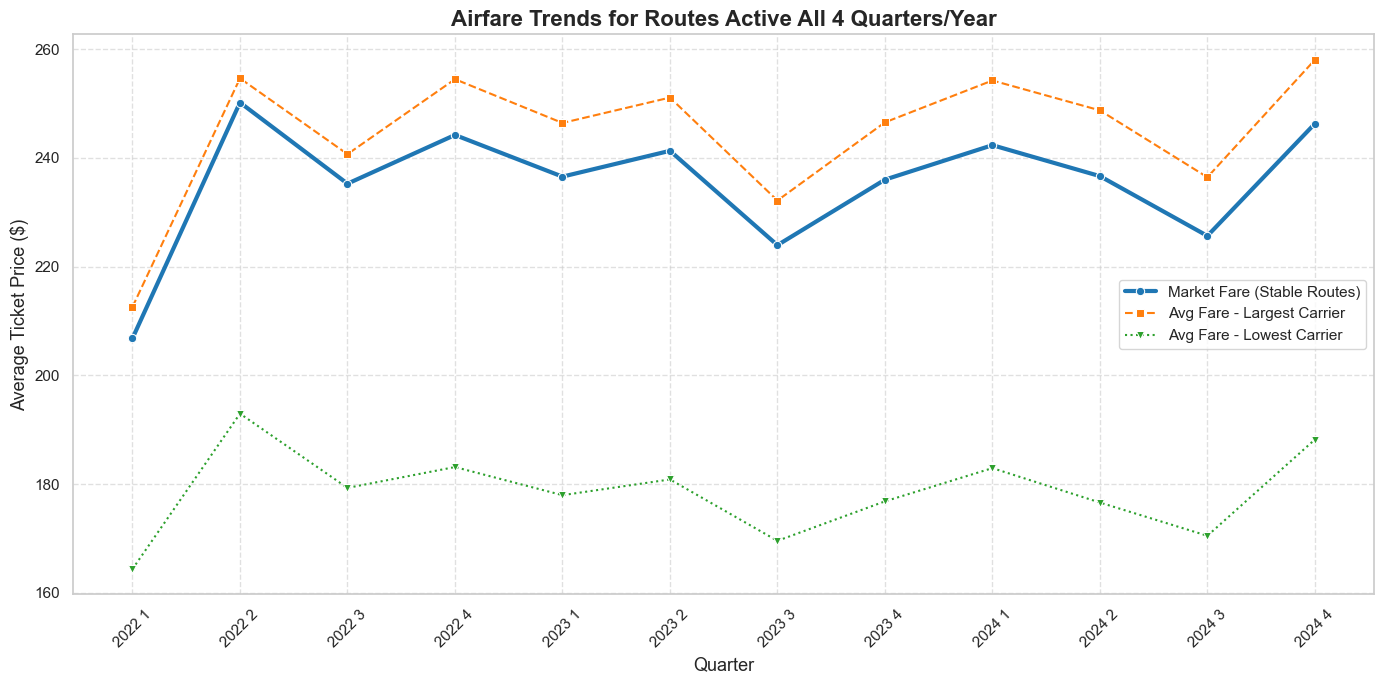

In [337]:
# Create the chronological Period label
df_filtered['Period'] = df_filtered['Year'].astype(str) + " " + df_filtered['quarter'].astype(str)

# Calculate averages per quarter
quarterly_stats = df_filtered.groupby(['Year', 'quarter', 'Period']).agg({
    'fare': 'mean',
    'fare_lg': 'mean',
    'fare_low': 'mean'
}).reset_index().sort_values(['Year', 'quarter'])

# Plotting the Graph
plt.figure(figsize=(14, 7))

sns.lineplot(data=quarterly_stats, x='Period', y='fare', marker='o', 
             label='Market Fare (Stable Routes)', linewidth=3, color='#1f77b4')

sns.lineplot(data=quarterly_stats, x='Period', y='fare_lg', marker='s', 
             label='Avg Fare - Largest Carrier', linestyle='--', color='#ff7f0e')

sns.lineplot(data=quarterly_stats, x='Period', y='fare_low', marker='v', 
             label='Avg Fare - Lowest Carrier', linestyle=':', color='#2ca02c')

# Styling
plt.title('Airfare Trends for Routes Active All 4 Quarters/Year', fontsize=16, fontweight='bold')
plt.ylabel('Average Ticket Price ($)', fontsize=13)
plt.xlabel('Quarter', fontsize=13)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()

# Model Testing

In [338]:
# Create Dummy Variables (Q1 is dropped as the baseline)
quarter_dummies = pd.get_dummies(df_filtered['quarter'], prefix='q', drop_first=True).astype(int)

# Combine with original features
X = quarter_dummies
X = sm.add_constant(X) # Adds the intercept
y = df_filtered['fare']

# Fit Model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     46.05
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           1.49e-29
Time:                        22:13:30   Log-Likelihood:                -57347.
No. Observations:               10380   AIC:                         1.147e+05
Df Residuals:                   10376   BIC:                         1.147e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        228.5924      1.192    191.832      0.0

### Insights
1. Q2 & Q4: The "Certainty" of Demand 
Both Q2 (+$14.1358) and **Q4 (+$13.5446) have extremely low p-values ($0.000$).
- The Takeaway: These quarters represent "Non-Discretionary" demand surges. In Q2 (Spring Break/Graduations) and Q4 (Holidays), consumers must fly. Airlines recognize this lack of flexibility and apply a structural premium of roughly $10 per ticket across the entire market, regardless of distance.

2. Q3: The "Competitive Neutrality" 
Your Q3 ($P>|t| = 0.852$) is the most interesting "negative result."
- The Takeaway: Q3 (July–September) is traditionally peak vacation time, yet the model says its prices aren't significantly different from the winter (Q1).
- The Why: This suggests that while demand is high in Q3, capacity is also at its highest. Airlines run their fullest schedules in the summer, and Low-Cost Carriers (LCCs) are most active then. The competition in Q3 "mops up" the potential price hikes, making it a more "efficient" market than the holiday-bottlenecked Q4.

In [339]:
# features
X = df_filtered[['TotalPerLFMkts_city2']]
X = sm.add_constant(X) # Adds the intercept
y = df_filtered['fare']

# Fit Model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     66.75
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.44e-16
Time:                        22:13:30   Log-Likelihood:                -57382.
No. Observations:               10380   AIC:                         1.148e+05
Df Residuals:                   10378   BIC:                         1.148e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  264.9149 